Лабораторна робота №4  
Тема: Інтерактивне дослідження гармонічного сигналу з шумом та його фільтрація  

Мета роботи: 
- Навчитися генерувати гармонічні сигнали з накладеним шумом.  
- Ознайомитися з методами фільтрації сигналів (Butterworth filter).  
- Розробити інтерактивний інтерфейс для дослідження сигналу у Jupyter Notebook.

Завдання:  
1. Реалізувати функцію `harmonic_with_noise`, яка генерує гармонічний сигнал з параметрами:  
   - Амплітуда (`amplitude`)  
   - Частота (`frequency`)  
   - Фазовий зсув (`phase`)  
   - Середнє значення шуму (`noise_mean`)  
   - Дисперсія шуму (`noise_covariance`)  
   - Прапорець показу шуму (`show_noise`)  |
2. Створити інтерактивне відображення сигналу з використанням:  
   - Слайдерів для параметрів гармоніки та шуму  
   - Чекбоксу для включення/вимкнення шуму  
   - Кнопки Reset для відновлення початкових параметрів  
   - Слайдерів для параметрів фільтра (`cutoff` та `order`)  
3. Відобразити на графіку:  
   - Чисту гармоніку  
   - Гармоніку з шумом (опціонально, залежно від прапорця)  
   - Відфільтровану гармоніку  
4. Забезпечити автоматичне оновлення графіка при зміні будь-якого параметру.

In [19]:
#імпорти
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import ipywidgets as widgets
from IPython.display import display

In [20]:
#функції
def harmonic_with_noise(t, amplitude, frequency, phase,
                        noise_mean, noise_covariance,
                        show_noise, existing_noise=None):
    
    y_clean = amplitude * np.sin(2 * np.pi * frequency * t + phase)

    if show_noise:
        if existing_noise is None:
            noise = np.random.normal(noise_mean, np.sqrt(noise_covariance), size=t.shape)
        else:
            noise = existing_noise
        y = y_clean + noise
    else:
        noise = existing_noise if existing_noise is not None else np.zeros_like(t)
        y = y_clean

    return y_clean, y, noise


def filter_signal(y, cutoff, fs, order):
    b, a = butter(order, cutoff / (0.5 * fs), btype='low')
    return filtfilt(b, a, y)

In [21]:
#дані
t = np.linspace(0, 2, 500)

init_params = {
    'amplitude':1.0,
    'frequency':1.0,
    'phase':0.0,
    'noise_mean':0.0,
    'noise_covariance':0.1,
    'show_noise':True
}

current_noise = None
prev_noise_mean = init_params['noise_mean']
prev_noise_cov = init_params['noise_covariance']

In [22]:
#UI
amplitude_slider = widgets.FloatSlider(value=1, min=0, max=5, step=0.1, description='Amplitude')
frequency_slider = widgets.FloatSlider(value=1, min=0.1, max=10, step=0.1, description='Frequency')
phase_slider = widgets.FloatSlider(value=0, min=0, max=2*np.pi, step=0.1, description='Phase')

noise_mean_slider = widgets.FloatSlider(value=0, min=-1, max=1, step=0.05, description='Noise Mean')
noise_cov_slider = widgets.FloatSlider(value=0.1, min=0, max=1, step=0.01, description='Noise Var')

show_noise_checkbox = widgets.Checkbox(value=True, description='Show Noise')

cutoff_slider = widgets.FloatSlider(value=0.2, min=0.01, max=1.0, step=0.01, description='Cutoff')
order_slider = widgets.IntSlider(value=4, min=1, max=10, description='Order')

reset_button = widgets.Button(description="Reset")

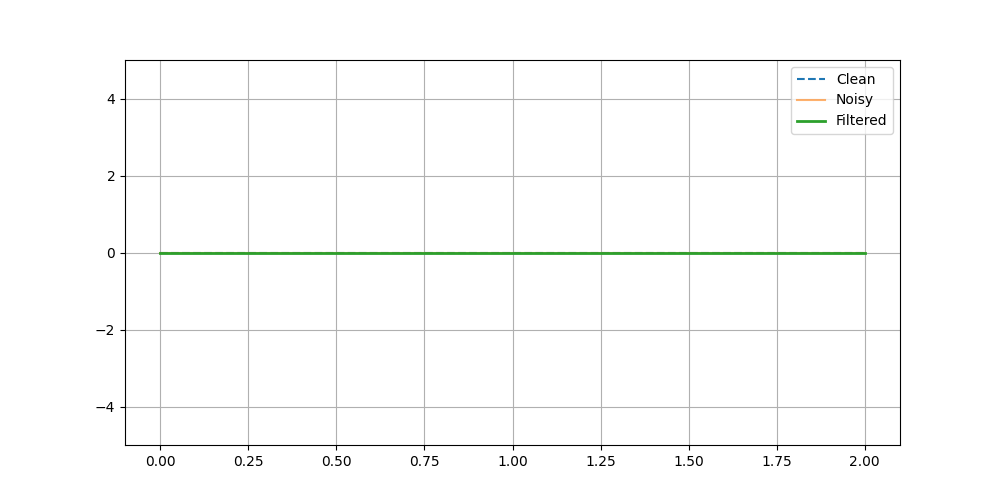

In [23]:
#графік
fig, ax = plt.subplots(figsize=(10,5))

line_clean, = ax.plot(t, np.zeros_like(t), linestyle='--', label='Clean')
line_noisy, = ax.plot(t, np.zeros_like(t), alpha=0.6, label='Noisy')
line_filtered, = ax.plot(t, np.zeros_like(t), linewidth=2, label='Filtered')

ax.set_ylim(-5,5)
ax.grid()
ax.legend()

In [24]:
def update_plot(change=None):
    global current_noise, prev_noise_mean, prev_noise_cov

    # Перевірка зміни шуму
    noise_changed = (
        noise_mean_slider.value != prev_noise_mean or
        noise_cov_slider.value != prev_noise_cov or
        current_noise is None
    )

    if noise_changed:
        current_noise = np.random.normal(
            noise_mean_slider.value,
            np.sqrt(noise_cov_slider.value),
            size=t.shape
        )
        prev_noise_mean = noise_mean_slider.value
        prev_noise_cov = noise_cov_slider.value

    # Сигнали
    y_clean, y_noisy, _ = harmonic_with_noise(
        t,
        amplitude_slider.value,
        frequency_slider.value,
        phase_slider.value,
        noise_mean_slider.value,
        noise_cov_slider.value,
        show_noise_checkbox.value,
        existing_noise=current_noise
    )

    # Фільтр
    fs = 1 / (t[1] - t[0])
    y_filtered = filter_signal(y_noisy, cutoff_slider.value, fs, order_slider.value)

    # Оновлення графіка
    line_clean.set_ydata(y_clean)

    if show_noise_checkbox.value:
        line_noisy.set_ydata(y_noisy)
        line_noisy.set_visible(True)
    else:
        line_noisy.set_visible(False)

    line_filtered.set_ydata(y_filtered)

    fig.canvas.draw_idle()

In [25]:
#reset
def reset_params(b):
    global current_noise

    amplitude_slider.value = 1
    frequency_slider.value = 1
    phase_slider.value = 0
    noise_mean_slider.value = 0
    noise_cov_slider.value = 0.1
    show_noise_checkbox.value = True
    cutoff_slider.value = 0.2
    order_slider.value = 4

    current_noise = None

In [26]:
#підключення
for w in [
    amplitude_slider, frequency_slider, phase_slider,
    noise_mean_slider, noise_cov_slider,
    show_noise_checkbox,
    cutoff_slider, order_slider
]:
    w.observe(update_plot, names='value')

reset_button.on_click(reset_params)


ui = widgets.VBox([
    widgets.HBox([amplitude_slider, frequency_slider, phase_slider]),
    widgets.HBox([noise_mean_slider, noise_cov_slider, show_noise_checkbox]),
    widgets.HBox([cutoff_slider, order_slider, reset_button])
])

display(ui)

update_plot()